
## FINANCIAL DATA
MODULE 5 | LESSON 4


---

# **PLOTTING AND THE TRANSITION MATRIX**



|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** | Ratings  |
|**Keywords** |Transition matrix, Loss Given Default (LGD), Matplotlib library |

---


*In this lesson, we compare the probabilities of default (PDs) that we estimated in the last lesson to ratings-implied PDs. We can do this because we will download the ratings agency transition matrix, which includes PD. We will also note that the PD increases with maturity by graphing, which means we will practice our graphing skills*.

**Note:** The code that was introduced in the previous lesson is below, followed by the new code and text for this lesson.

In [1]:
from datetime import date
from datetime import datetime as dt
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yfin
from sympy import solve, symbols

yfin.pdr_override()

In [2]:
# Loading the appropriate .csv bond data file
bond_prices_df = pd.read_csv("bond-prices.csv")

bond_prices_df

,Issuer Name,Symbol,Callable,Sub-Product Type,Coupon,Maturity,Moody's®,S&P,Price,Yield
0,HESS CORP,HES.GH,Yes,Corporate Bond,6.000,01/15/2040,Baa3,BBB-,103.276,5.702
1,HESS CORP,HES.GI,Yes,Corporate Bond,5.600,02/15/2041,Baa3,BBB-,98.664,5.717
2,HESS CORP,HES4136877,Yes,Corporate Bond,3.500,07/15/2024,Baa3,BBB-,98.772,4.139
3,HESS CORP,HES4405829,Yes,Corporate Bond,4.300,04/01/2027,Baa3,BBB-,99.512,4.414
4,HESS CORP,HES4405830,Yes,Corporate Bond,5.800,04/01/2047,Baa3,BBB-,101.269,5.702
5,HESS MIDSTREAM OPERATIONS LP,HES5392919,Yes,Corporate Bond,5.500,10/15/2030,Ba2,BB+,89.594,7.188
6,HESS MIDSTREAM OPERATIONS LP,HES4567499,Yes,Corporate Bond,5.625,02/15/2026,WR,BB+,104.500,4.431
7,HESS MIDSTREAM OPERATIONS LP,HES4927355,Yes,Corporate Bond,5.625,02/15/2026,NaN,BB+,95.520,7.051
8,HESS MIDSTREAM OPERATIONS LP,HES5233164,Yes,Corporate Bond,4.250,02/15/2030,Ba2,BB+,84.818,6.843
9,HESS MIDSTREAM PARTNERS LP,HES4918686,Yes,Corporate Bond,5.125,06/15/2028,Ba2,BB+,90.268,7.164


In [3]:
def bond_dataframe_filter(df):
    # Drop bonds with missing yields and missing credit ratings
    df["Yield"].replace("", np.nan, inplace=True)
    df["Moody's®"].replace({"WR": np.nan, "": np.nan}, inplace=True)
    df["S&P"].replace({"NR": np.nan, "": np.nan}, inplace=True)
    df = df.dropna(subset=["Yield"])
    df = df.dropna(subset=["Moody's®"])
    df = df.dropna(subset=["S&P"])

    # Create Maturity Years column that aligns with Semi-Annual Payments from corporate bonds
    df["Yield"] = df["Yield"].astype(float)
    df["Coupon"] = df["Coupon"].astype(float)
    df["Price"] = df["Price"].astype(float)
    now = dt.strptime(date.today().strftime("%m/%d/%Y"), "%m/%d/%Y")
    df["Maturity"] = pd.to_datetime(df["Maturity"]).dt.strftime("%m/%d/%Y")
    daystillmaturity = []
    yearstillmaturity = []
    for maturity in df["Maturity"]:
        daystillmaturity.append((dt.strptime(maturity, "%m/%d/%Y") - now).days)
        yearstillmaturity.append((dt.strptime(maturity, "%m/%d/%Y") - now).days / 360)
    df = df.reset_index(drop=True)
    df["Maturity"] = pd.Series(daystillmaturity)
    #         `df['Maturity Years'] = pd.Series(yearstillmaturity).round()` # Better for Annual Payments
    df["Maturity Years"] = (
        round(pd.Series(yearstillmaturity) / 0.5) * 0.5
    )  # Better for Semi-Annual Payments

    # Target bonds with short-term maturities
    df["Maturity"] = df["Maturity"].astype(float)
    # `df = df.loc[df['Maturity'] >= 0]`
    years_mask = (df["Maturity Years"] > 0) & (df["Maturity Years"] <= 5)
    df = df.loc[years_mask]
    return df

In [4]:
bond_df_result = bond_dataframe_filter(bond_prices_df)
bond_df_result

/tmp/ipykernel_1648/3288264741.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Yield"].replace("", np.nan, inplace=True)
/tmp/ipykernel_1648/3288264741.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

,Issuer Name,Symbol,Callable,Sub-Product Type,Coupon,Maturity,Moody's®,S&P,Price,Yield,Maturity Years
3,HESS CORP,HES4405829,Yes,Corporate Bond,4.300,933.0,Baa3,BBB-,99.512,4.414,2.5
7,HESS MIDSTREAM PARTNERS LP,HES4918686,Yes,Corporate Bond,5.125,1374.0,Ba2,BB+,90.268,7.164,4.0


In [5]:
# Ten-Year Risk-free Rate
timespan = 100
current_date = date.today()
past_date = current_date - timedelta(days=timespan)
ten_year_risk_free_rate_df = yfin.download("^TNX", past_date, current_date)
ten_year_risk_free_rate = (
    ten_year_risk_free_rate_df.iloc[len(ten_year_risk_free_rate_df) - 1, 4]
) / 100
ten_year_risk_free_rate

[*********************100%%**********************]  1 of 1 completed


0.03697000026702881

In [6]:
# Market Risk Premium
market_risk_premium = 0.0472

In [7]:
# Market Equity Beta
stock_market_beta = 1

In [8]:
# Market Rate of Return
market_rate_of_return = ten_year_risk_free_rate + (
    stock_market_beta * market_risk_premium
)
market_rate_of_return

0.08417000026702881

In [9]:
# Vanguard Short-Term Corporate Bond Index Fund ETF Shares
bond_fund_ticker = "VCSH"

In [10]:
# Download data for the bond fund and the market
market_data = yfin.download("SPY", past_date, current_date)  # the market
fund_data = yfin.download("VCSH", past_date, current_date)  # the bond fund

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [11]:
# Approach #1 - Covariance/Variance Method:

# Calculate the covariance between the fund and the market -- this is the numerator in the Beta calculation
fund_market_cov = (
    fund_data["Adj Close"].pct_change().cov(market_data["Adj Close"].pct_change())
)
print("covariance between fund and market: ", fund_market_cov)

# Calculate market (S&P) variance -- this is the denominator in the Beta calculation
market_var = market_data["Adj Close"].pct_change().var()
print("market variance: ", market_var)

# Calculate Beta
bond_fund_beta_cv = fund_market_cov / market_var
print("bond fund beta (using covariance/variance): ", bond_fund_beta_cv)

covariance between fund and market:  5.530700810982246e-07
market variance:  9.042731691892857e-05
bond fund beta (using covariance/variance):  0.006116183692523714


In [12]:
# Approach #2 - Correlation Method:

# Calculate the standard deviation of the market by taking the square root of the variance, for use in the denominator
market_stdev = market_var**0.5
print("market standard deviation: ", market_stdev)

# Calculate bond fund standard deviation, for use in the numerator

fund_stdev = fund_data["Adj Close"].pct_change().std()
print("fund standard deviation: ", fund_stdev)

# Calculate Pearson correlation between bond fund and market (S&P), for use in the numerator
fund_market_Pearson_corr = (
    fund_data["Adj Close"]
    .pct_change()
    .corr(market_data["Adj Close"].pct_change(), method="pearson")
)
print("Pearson correlation between fund and market: ", fund_market_Pearson_corr)

# Calculate Beta
fund_beta_corr = fund_stdev * fund_market_Pearson_corr / market_stdev
print("bond fund beta (using correlation): ", fund_beta_corr)

market standard deviation:  0.00950932788996828
fund standard deviation:  0.001385291191526427
Pearson correlation between fund and market:  0.04198452752983914
bond fund beta (using correlation):  0.0061161836925237145


In [13]:
# Bond's Beta: use the result of either of the two above approaches, bond_fund_beta_cv or fund_beta_corr
bond_beta = fund_beta_corr
bond_beta

0.0061161836925237145

In [14]:
# Expected Risk Premium
expected_risk_premium = (market_rate_of_return - ten_year_risk_free_rate) * bond_beta
expected_risk_premium

0.0002886838702871193

In [15]:
# Risk-adjusted Discount Rate
risk_adjusted_discount_rate = ten_year_risk_free_rate + expected_risk_premium
risk_adjusted_discount_rate

0.03725868413731593

In [16]:
def bonds_probability_of_default(
    coupon, maturity_years, bond_price, principal_payment, risk_adjusted_discount_rate
):
    price = bond_price
    prob_default_exp = 0

    #     `times = np.arange(1, maturity_years+1)` # For Annual Cashflows
    #     annual_coupon = coupon # For Annual Cashflows
    times = np.arange(0.5, (maturity_years - 0.5) + 1, 0.5)  # For Semi-Annual Cashflows
    semi_annual_coupon = coupon / 2  # For Semi-Annual Cashflows

    # Calculation of Expected Cash Flow
    cashflows = np.array([])
    for i in times[:-1]:
        #         cashflows = np.append(cashflows, annual_coupon) # For Annual Cashflows
        #     cashflows = np.append(cashflows, annual_coupon+principal_payment)#  For Annual Cashflows
        cashflows = np.append(
            cashflows, semi_annual_coupon
        )  # For Semi-Annual Cashflows
    cashflows = np.append(
        cashflows, semi_annual_coupon + principal_payment
    )  # For Semi-Annual Cashflows

    for i in range(len(times)):
        #         This code block is used if there is only one payment remaining
        if len(times) == 1:
            prob_default_exp += (
                cashflows[i] * (1 - P) + cashflows[i] * recovery_rate * P
            ) / np.power((1 + risk_adjusted_discount_rate), times[i])
        #         This code block is used if there are multiple payments remaining
        else:
            #             For Annual Cashflows
            #             if times[i] == 1:
            #                 prob_default_exp += ((cashflows[i]*(1-P) + principal_payment*recovery_rate*P) / \
            #                                     np.power((1 + risk_adjusted_discount_rate), times[i]))
            #             For Semi-Annual Cashflows
            if times[i] == 0.5:
                prob_default_exp += (
                    cashflows[i] * (1 - P) + principal_payment * recovery_rate * P
                ) / np.power((1 + risk_adjusted_discount_rate), times[i])
            #             Used for either Annual or Semi-Annual Cashflows
            else:
                prob_default_exp += (
                    np.power((1 - P), times[i - 1])
                    * (cashflows[i] * (1 - P) + principal_payment * recovery_rate * P)
                ) / np.power((1 + risk_adjusted_discount_rate), times[i])

    prob_default_exp = prob_default_exp - price
    implied_prob_default = solve(prob_default_exp, P)
    implied_prob_default = round(float(implied_prob_default[0]) * 100, 2)

    if implied_prob_default < 0:
        return 0.0
    else:
        return implied_prob_default

In [17]:
# Variables defined for bonds_probability_of_default function
principal_payment = 100
recovery_rate = 0.40
P = symbols("P")

In [18]:
# This calculation may take some time if there are many coupon payments
bond_df_result["Probability of Default %"] = bond_df_result.head(1).apply(
    lambda row: bonds_probability_of_default(
        row["Coupon"],
        row["Maturity Years"],
        row["Price"],
        principal_payment,
        risk_adjusted_discount_rate,
    ),
    axis=1,
)

bond_df_result.head(1)

,Issuer Name,Symbol,Callable,Sub-Product Type,Coupon,Maturity,Moody's®,S&P,Price,Yield,Maturity Years,Probability of Default %
3,HESS CORP,HES4405829,Yes,Corporate Bond,4.3,933.0,Baa3,BBB-,99.512,4.414,2.5,1.88


## 1. Credit Ratings
As you recall from the Financial Markets course, credit ratings are used for bonds issued by corporations and government entities as well as for asset-backed securities (ABS) and mortgage-backed securities (MBS). The three major global credit rating agencies are Moody's Investors Service, Standard & Poor's, and Fitch Ratings. Each provides credit quality ratings for issuers as well as specific issues. These are ordinal ratings focusing on the probability of default.

The credit rating agencies consider the expected loss given default (LGD) by means of **notching**, which is an adjustment to the issuer rating to reflect the priority of claim for specific debt issues of that issuer and to reflect any subordination. The issuer rating is typically for senior unsecured debt. The rating on subordinated debt is then adjusted, or "notched" by lowering it one or two levels - for instance, from A+ down to A or further down to A-. This inclusion of loss given default in addition to the probability of default explains why they are called "credit ratings" and not just "default ratings."

The rating agencies report transition matrices based on their historical data. A transition matrix shows the probability that a rating changes (or stays the same) in one year's time. (The probability that the rating changes to default is the probability of default.)

We can verify the accuracy of the market-implied default probabilities with these rating agencies' transition matrices. Using the code below, we can obtain the Standard & Poor's Average One-Year Transition Rates For Global Corporates using historical data from 1981-2019 to verify the market-implied default probabilities calculated earlier.

## 2. Plotting

To get ready for the graphing below, please make sure you do all the required readings for this lesson and lesson 3.
<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [19]:
def prob_default_term_structure(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, clear=True)
    fig.subplots_adjust(wspace=0.5)
    Mgroups = df.groupby("Moody's®")
    ax1.clear()
    ax1.margins(0.5)
    ax1.set_xlabel("Days Until Maturity")
    ax1.set_ylabel("Probability of Default %")
    ax1.set_title("Moody's® Ratings")
    for name, group in Mgroups:
        ax1.plot(
            group["Maturity"],
            group["Probability of Default %"],
            marker="o",
            linestyle="",
            ms=12,
            label=name,
        )
    ax1.legend(loc="upper left")

    SPgroups = df.groupby("S&P")
    ax2.clear()
    ax2.margins(0.5)
    ax2.set_xlabel("Days Until Maturity")
    ax2.set_ylabel("Probability of Default %")
    ax2.set_title("S&P Ratings")

    for name, group in SPgroups:
        ax2.plot(
            group["Maturity"],
            group["Probability of Default %"],
            marker="o",
            linestyle="",
            ms=12,
            label=name,
        )
    ax2.legend(loc="upper left")
    plt

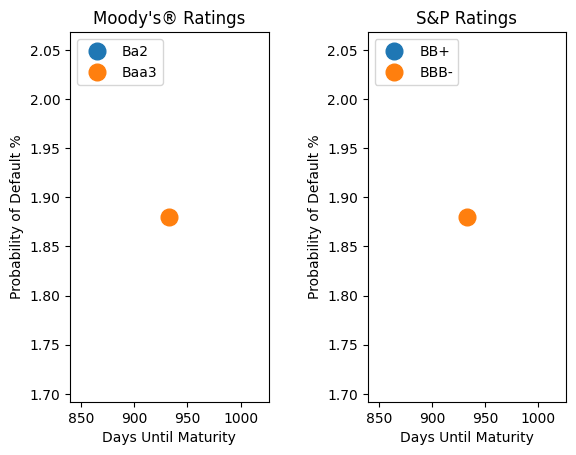

In [20]:
prob_default_term_structure(bond_df_result)

## 3. Downloading the Transition Matrix


In [21]:
tgt_website = r"https://www.spglobal.com/ratings/en/research/articles/200429-default-transition-and-recovery-2019-annual-global-corporate-default-and-rating-transition-study-11444862"

In [22]:
def get_transition_matrix(tgt_website):
    df_list = pd.read_html(tgt_website)
    matrix_result_df = df_list[22]

    return matrix_result_df


scrape_new_data = False
if scrape_new_data:
    transition_matrix_df = get_transition_matrix(tgt_website)
else:
    transition_matrix_df = pd.read_csv("transition-matrix.csv")

In [23]:
sp_clean_result_df = pd.DataFrame(transition_matrix_df.iloc[:34, :19].dropna(axis=0))
sp_clean_result_df

,From/to,AAA,AA+,AA,AA-,A+,A,A-,BBB+,BBB,BBB-,BB+,BB,BB-,B+,B,B-,CCC,D
0,AAA,87.03,5.89,2.51,0.69,0.16,0.24,0.13,0.00,0.05,0.00,0.03,0.05,0.03,0.00,0.03,0.00,0.05,0.00
2,AA+,2.31,78.94,10.91,3.54,0.71,0.33,0.19,0.05,0.09,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,AA,0.42,1.31,80.76,8.53,2.72,1.15,0.36,0.39,0.13,0.08,0.05,0.03,0.02,0.02,0.00,0.02,0.05,0.02
6,AA-,0.04,0.11,3.77,78.80,9.68,2.19,0.60,0.25,0.15,0.07,0.03,0.00,0.00,0.03,0.08,0.00,0.00,0.03
8,A+,0.00,0.06,0.44,4.44,78.38,8.73,2.15,0.61,0.34,0.09,0.06,0.09,0.01,0.07,0.03,0.00,0.00,0.05
10,A,0.03,0.04,0.22,0.41,5.32,78.88,6.74,2.38,0.86,0.27,0.10,0.10,0.06,0.08,0.02,0.00,0.01,0.05
12,A-,0.04,0.01,0.06,0.15,0.42,6.49,78.12,7.23,1.98,0.57,0.13,0.13,0.11,0.10,0.02,0.01,0.03,0.06
14,BBB+,0.00,0.01,0.05,0.06,0.20,0.74,7.13,75.83,7.98,1.56,0.36,0.29,0.13,0.15,0.10,0.02,0.06,0.10
16,BBB,0.01,0.01,0.04,0.03,0.10,0.31,1.00,7.73,76.00,6.11,1.34,0.58,0.27,0.22,0.11,0.03,0.05,0.16
18,BBB-,0.01,0.01,0.02,0.04,0.06,0.14,0.25,1.17,9.31,72.40,5.47,2.08,0.83,0.36,0.22,0.16,0.21,0.25


The above is the Standard & Poor's 2019 transition matrix. It shows the probabilities of a particular rating transitioning to another over the course of the following year. An A-rated issuer has a 78.88% probability of remaining at that level, a 0.03% probability of moving up to AAA; a 0.22% probability of moving up to AA; an 0.86% probability of moving down to BBB; 0.10% down to BB; 0.02% to B, 0.01% to CCC, CC, or C; and 0.05% to D, where it is in default.

Using the Selenium script mentioned earlier to retrieve the Standard & Poor's credit ratings, we can use the corporate bond's credit rating to determine the probability of a particular rating transitioning to D (default) during the next year according to the Standard & Poor's 2019 transition matrix.

In [24]:
# Will scrape the default probability for each rating

sp_rating_list = [
    "AAA",
    "AA+",
    "AA",
    "AA-",
    "A+",
    "A",
    "A-",
    "BBB+",
    "BBB",
    "BBB-",
    "BB+",
    "BB",
    "BB-",
    "B+",
    "B",
    "B-",
]

ccc_list = ["CCC+", "CCC", "CCC-", "CC+", "CC", "CC-", "C+", "C", "C-"]

sp_rating = None

for i in sp_rating_list:
    if bond_df_result["S&P"].iloc[0] == i:
        sp_rating = bond_df_result["S&P"].iloc[0]

if sp_rating is None:
    for i in ccc_list:
        if bond_df_result["S&P"].iloc[0] == i:
            sp_rating = "CCC/C"

sp_transition_dp = 0

for i in range(33):
    if transition_matrix_df.loc[i][0] == sp_rating:
        sp_transition_dp += float(sp_clean_result_df.loc[i][18])

sp_transition_dp

/tmp/ipykernel_1648/1210709522.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if transition_matrix_df.loc[i][0] == sp_rating:
/tmp/ipykernel_1648/1210709522.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sp_transition_dp += float(sp_clean_result_df.loc[i][18])


0.25

It appears that the market-implied probability of default we calculated for the nearest maturity corporate bond is close to the probability of default as determined from the historical data in the Standard & Poor's 2019 transition matrix.

In [25]:
# Compare the nearest maturity Market-implied probability of default with
# the historical probability of default in the Standard & Poor's 2019 transition matrix
print(
    "Market-implied probability of default = %s"
    % (bond_df_result["Probability of Default %"].iloc[0])
    + "%"
)
print("Standard & Poor's probability of default = %s" % (sp_transition_dp) + "%")

Market-implied probability of default = 1.88%
Standard & Poor's probability of default = 0.25%


## 4. Conclusion

In the example above, the bond valuation techniques using a risk-adjusted discount rate do a reasonably good job of estimating the market-implied default probabilities. We calculated the expected cash flow at each period by adding the product of the default payout and the probability of default ($p$) with the product of the promised payment (coupon payments and repayment of principal) and the probability of not defaulting ($1-p$). One reason for any differences between historical and market-implied default probabilities is that historical default probabilities do not include the default risk premium associated with uncertainty over the timing of possible default loss.

The model used here is very sensitive to the discount and recovery rates selected. For simplicity, we assume a flat government bond yield curve, but it could be upward or downward sloping. A more sophisticated and realistic model of the discount rates would require that they be calculated sequentially by a process known as "bootstrapping." We also assume in this example that the recovery rate is 40%, but another possibility is to change the assumed recovery rate to either 30% or 60% of exposure. Another simplifying assumption is that recovery is instantaneous. In practice, lengthy time delays can occur between the event of default and eventual recovery of cash. Notice that we assume that the recovery rate applies to interest as well as principal.

Also, we assume that default occurs only on coupon payment dates and that default will not occur on date 0, the current date. Although we assumed the annual default probability is the same each year, this does not need to be the case.

Even with the assumptions made in this analysis, the market-implied probability of default model built here does a fairly good job at identifying risk of corporate defaults and may suffice for simply rank ordering firms by credit worthiness.

**References**

* Vanderplas, Jake. "04.00-Introduction-To-Matplotlib.ipynb." *GitHub*, https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb
* Sargent, Thomas, and John Stachurski. "10. Matplotlib." *Python Programming for Economics and Finance*. https://python-programming.quantecon.org/matplotlib.html.
* Coleman, Chase, et al. "GroupBy." *QuantEcon DataScience.* https://datascience.quantecon.org/pandas/groupby.html
* The  code and related documentation used in this lesson is adapted from: <br>**Hugh Donnelly, CFA**<br>*AlphaWave Data* <br> **March 2021** under the following  MIT License:

> Copyright (c) 2020 HDVI <br>Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:<br>The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.<br>THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

**Note:** The above MIT license notice is copied here to comply with its requirements but it does **not** apply to the content in these lesson notes.


---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
